In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Library berhasil diimport!")

Library berhasil diimport!


In [2]:
# Load semua file CSV
orders    = pd.read_csv('../data/raw/olist_orders_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
items     = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
payments  = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews   = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products  = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers   = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
category  = pd.read_csv('../data/raw/product_category_name_translation.csv')

# Ringkasan semua dataset
datasets = {
    'orders'   : orders,
    'customers': customers,
    'items'    : items,
    'payments' : payments,
    'reviews'  : reviews,
    'products' : products,
    'sellers'  : sellers,
    'category' : category,
}

print("RINGKASAN DATASET: \n")
for nama, df in datasets.items():
    print(f"{nama:<12} → {df.shape[0]:>7,} baris | {df.shape[1]:>2} kolom")

RINGKASAN DATASET: 

orders       →  99,441 baris |  8 kolom
customers    →  99,441 baris |  5 kolom
items        → 112,650 baris |  7 kolom
payments     → 103,886 baris |  5 kolom
reviews      →  99,224 baris |  7 kolom
products     →  32,951 baris |  9 kolom
sellers      →   3,095 baris |  4 kolom
category     →      71 baris |  2 kolom


In [4]:
# Gabungkan semua tabel menjadi satu dataframe utama
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(items, on='order_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(category, on='product_category_name', how='left')
df = df.merge(sellers, on='seller_id', how='left')

# Konversi kolom tanggal
kolom_tanggal = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in kolom_tanggal:
    df[col] = pd.to_datetime(df[col])

# Tambah kolom turunan
df['bulan_transaksi'] = df['order_purchase_timestamp'].dt.to_period('M')
df['tahun']           = df['order_purchase_timestamp'].dt.year
df['nama_bulan']      = df['order_purchase_timestamp'].dt.strftime('%b')
df['hari_dalam_seminggu'] = df['order_purchase_timestamp'].dt.day_name()

print(f"Dataset gabungan berhasil dibuat!")
print(f"  Jumlah baris  : {df.shape[0]:,}")
print(f"  Jumlah kolom  : {df.shape[1]}")
print(f"\nKolom yang tersedia:")
for col in df.columns:
    print(f"  - {col}")

Dataset gabungan berhasil dibuat!
  Jumlah baris  : 118,434
  Jumlah kolom  : 38

Kolom yang tersedia:
  - order_id
  - customer_id
  - order_status
  - order_purchase_timestamp
  - order_approved_at
  - order_delivered_carrier_date
  - order_delivered_customer_date
  - order_estimated_delivery_date
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state
  - order_item_id
  - product_id
  - seller_id
  - shipping_limit_date
  - price
  - freight_value
  - payment_sequential
  - payment_type
  - payment_installments
  - payment_value
  - product_category_name
  - product_name_lenght
  - product_description_lenght
  - product_photos_qty
  - product_weight_g
  - product_length_cm
  - product_height_cm
  - product_width_cm
  - product_category_name_english
  - seller_zip_code_prefix
  - seller_city
  - seller_state
  - bulan_transaksi
  - tahun
  - nama_bulan
  - hari_dalam_seminggu


In [ ]:
#PEMBERSIHAN DATA

df_clean = df.copy()

# 1. Hanya ambil transaksi yang sudah selesai
print(f"Status transaksi yang ada:")
print(df_clean['order_status'].value_counts())

df_clean = df_clean[df_clean['order_status'] == 'delivered']
print(f"\nSetelah filter 'delivered': {len(df_clean):,} baris")

# 2. Hapus baris tanpa harga atau produk
df_clean = df_clean.dropna(subset=['price', 'product_id', 'seller_id'])
print(f"Setelah hapus baris kosong: {len(df_clean):,} baris")

# 3. Tambah kolom total nilai transaksi per item
df_clean['total_item'] = df_clean['price'] + df_clean['freight_value']

# 4. Tambah kolom selisih estimasi vs aktual pengiriman (dalam hari)
df_clean['selisih_pengiriman'] = (
    df_clean['order_estimated_delivery_date'] -
    df_clean['order_delivered_customer_date']
).dt.days

# Positif = lebih cepat dari estimasi, Negatif = terlambat
df_clean['terlambat'] = df_clean['selisih_pengiriman'] < 0

print(f"\nRINGKASAN SETELAH PEMBERSIHAN:")
print(f"Total transaksi selesai : {df_clean['order_id'].nunique():,}")
print(f"Total produk unik       : {df_clean['product_id'].nunique():,}")
print(f"Total penjual aktif     : {df_clean['seller_id'].nunique():,}")
print(f"Total pembeli unik      : {df_clean['customer_unique_id'].nunique():,}")
print(f"Transaksi terlambat     : {df_clean['terlambat'].sum():,} ({df_clean['terlambat'].mean()*100:.1f}%)")
print(f"Rentang waktu           : {df_clean['order_purchase_timestamp'].min().date()} s/d {df_clean['order_purchase_timestamp'].max().date()}")

Status transaksi yang ada:
order_status
delivered      115038
shipped          1245
canceled          745
unavailable       650
processing        375
invoiced          373
created             5
approved            3
Name: count, dtype: int64

Setelah filter 'delivered': 115,038 baris
Setelah hapus baris kosong: 115,038 baris

RINGKASAN SETELAH PEMBERSIHAN:
Total transaksi selesai : 96,478
Total produk unik       : 32,216
Total penjual aktif     : 2,970
Total pembeli unik      : 93,358
Transaksi terlambat     : 9,026 (7.8%)
Rentang waktu           : 2016-09-15 s/d 2018-08-29


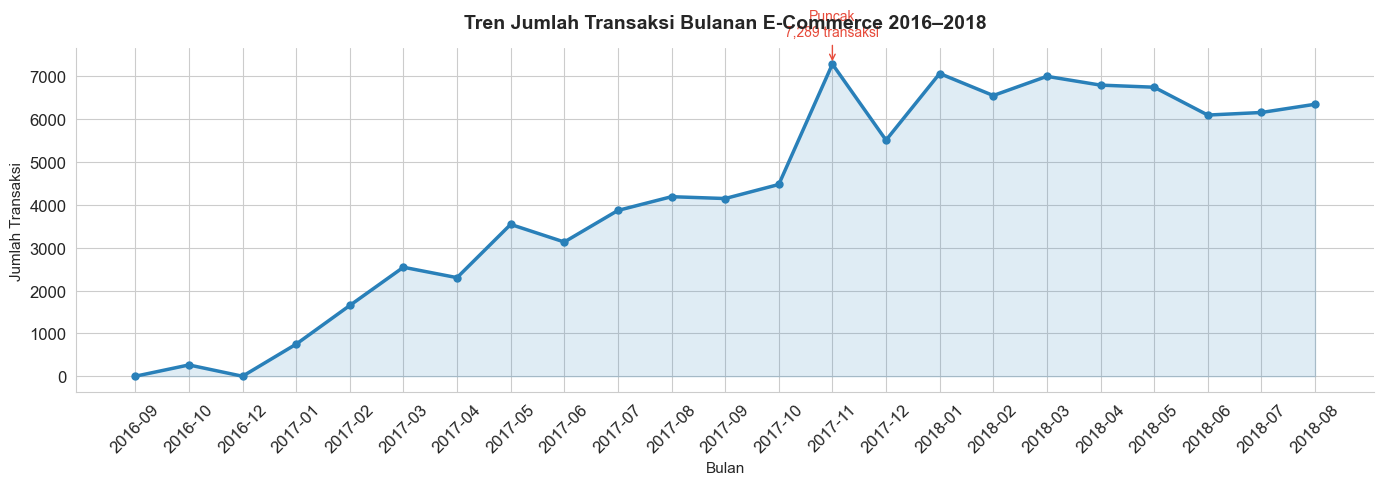

Grafik berhasil disimpan!


In [8]:
#VISUALISASI 1: TREN TRANSAKSI BULANAN

tren = df_clean.groupby('bulan_transaksi')['order_id'].nunique().reset_index()
tren.columns = ['bulan', 'jumlah_transaksi']
tren['bulan_str'] = tren['bulan'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(tren['bulan_str'], tren['jumlah_transaksi'],
                alpha=0.15, color='#2980b9')
ax.plot(tren['bulan_str'], tren['jumlah_transaksi'],
        color='#2980b9', linewidth=2.5, marker='o', markersize=5)

# Tandai bulan tertinggi
idx_max = tren['jumlah_transaksi'].idxmax()
ax.annotate(f"Puncak\n{tren.loc[idx_max, 'jumlah_transaksi']:,} transaksi",
            xy=(tren.loc[idx_max, 'bulan_str'], tren.loc[idx_max, 'jumlah_transaksi']),
            xytext=(0, 20), textcoords='offset points',
            ha='center', fontsize=10, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

ax.set_title('Tren Jumlah Transaksi Bulanan E-Commerce 2016–2018',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Jumlah Transaksi', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/viz1_tren_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik berhasil disimpan!")

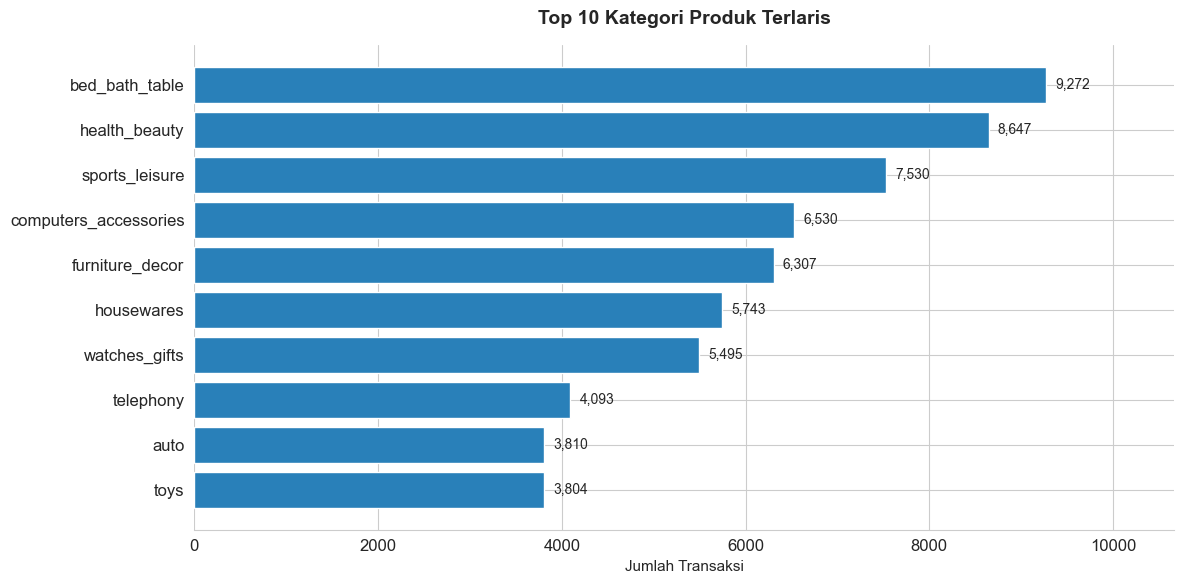

Grafik berhasil disimpan!


In [9]:
#VISUALISASI 2: TOP 10 KATEGORI PRODUK TERLARIS

top_kategori = (
    df_clean.groupby('product_category_name_english')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_kategori.columns = ['kategori', 'jumlah_transaksi']

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_kategori['kategori'][::-1],
               top_kategori['jumlah_transaksi'][::-1],
               color='#2980b9', edgecolor='white')

# Label angka di ujung bar
for bar in bars:
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}",
            va='center', fontsize=10)

ax.set_title('Top 10 Kategori Produk Terlaris',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Transaksi', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, top_kategori['jumlah_transaksi'].max() * 1.15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig('../data/viz2_top_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik berhasil disimpan!")

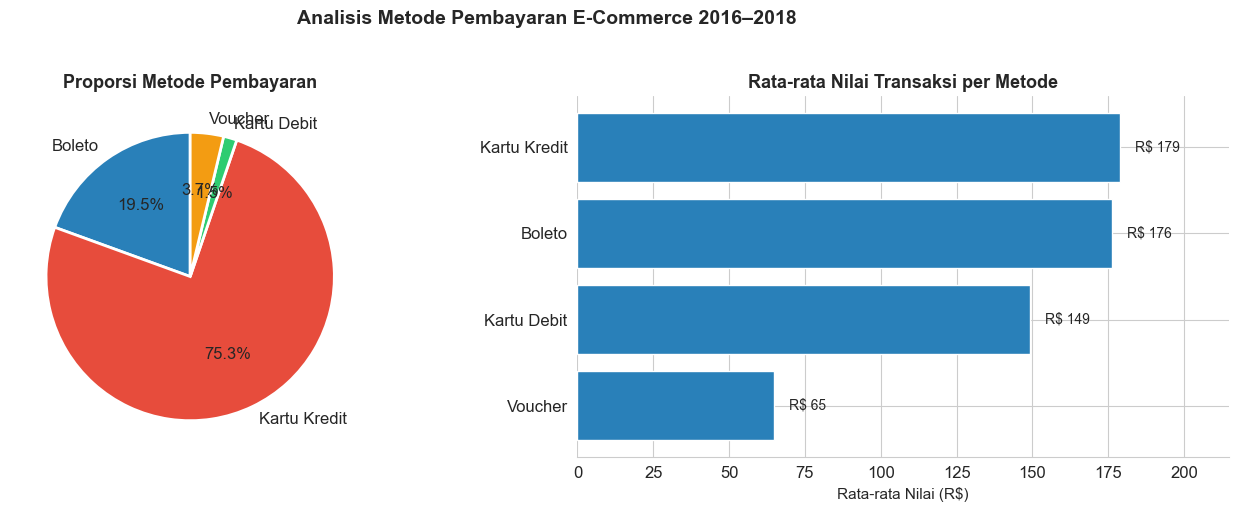

Grafik berhasil disimpan!


In [10]:
#VISUALISASI 3: METODE PEMBAYARAN & RATA-RATA NILAI TRANSAKSI

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Grafik kiri: proporsi metode pembayaran
payment_count = df_clean.groupby('payment_type')['order_id'].nunique()
label_map = {
    'credit_card' : 'Kartu Kredit',
    'boleto'      : 'Boleto',
    'voucher'     : 'Voucher',
    'debit_card'  : 'Kartu Debit',
    'not_defined' : 'Tidak Diketahui'
}
payment_count.index = payment_count.index.map(lambda x: label_map.get(x, x))
warna = ['#2980b9', '#e74c3c', '#2ecc71', '#f39c12', '#95a5a6']

ax1.pie(payment_count.values,
        labels=payment_count.index,
        autopct='%1.1f%%',
        colors=warna,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Proporsi Metode Pembayaran', fontsize=13, fontweight='bold')

#Grafik kanan: rata-rata nilai transaksi per metode
payment_avg = (
    df_clean.groupby('payment_type')['payment_value']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
payment_avg['payment_type'] = payment_avg['payment_type'].map(
    lambda x: label_map.get(x, x))

bars = ax2.barh(payment_avg['payment_type'],
                payment_avg['payment_value'],
                color='#2980b9', edgecolor='white')

for bar in bars:
    ax2.text(bar.get_width() + 5,
             bar.get_y() + bar.get_height()/2,
             f"R$ {bar.get_width():.0f}",
             va='center', fontsize=10)

ax2.set_title('Rata-rata Nilai Transaksi per Metode', fontsize=13, fontweight='bold')
ax2.set_xlabel('Rata-rata Nilai (R$)', fontsize=11)
ax2.set_xlim(0, payment_avg['payment_value'].max() * 1.2)
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.tick_params(left=False)

plt.suptitle('Analisis Metode Pembayaran E-Commerce 2016–2018',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/viz3_pembayaran.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik berhasil disimpan!")

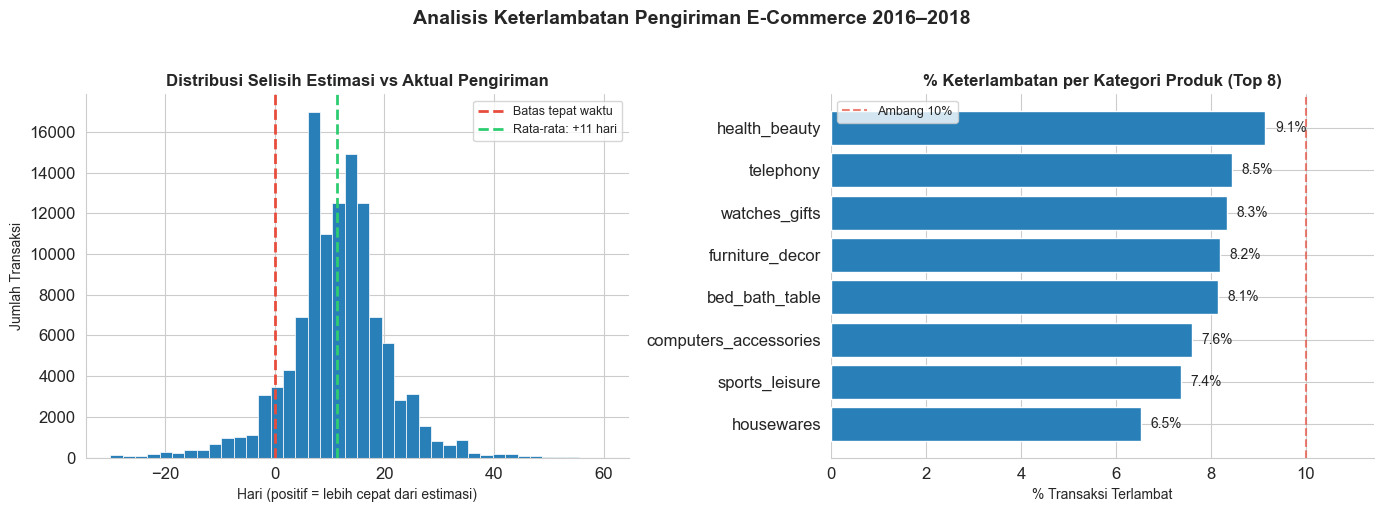

Grafik berhasil disimpan!


In [11]:
#VISUALISASI 4: ANALISIS KETERLAMBATAN PENGIRIMAN

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Grafik kiri: distribusi selisih pengiriman
data_pengiriman = df_clean['selisih_pengiriman'].dropna()
data_pengiriman = data_pengiriman[data_pengiriman.between(-30, 60)]

ax1.hist(data_pengiriman, bins=40, color='#2980b9',
         edgecolor='white', linewidth=0.5)
ax1.axvline(x=0, color='#e74c3c', linestyle='--',
            linewidth=2, label='Batas tepat waktu')
ax1.axvline(x=data_pengiriman.mean(), color='#2ecc71',
            linestyle='--', linewidth=2,
            label=f'Rata-rata: +{data_pengiriman.mean():.0f} hari')

ax1.set_title('Distribusi Selisih Estimasi vs Aktual Pengiriman',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Hari (positif = lebih cepat dari estimasi)', fontsize=10)
ax1.set_ylabel('Jumlah Transaksi', fontsize=10)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

#Grafik kanan: % terlambat per kategori top 8
top8 = (
    df_clean.groupby('product_category_name_english')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(8)
    .index
)

terlambat_kategori = (
    df_clean[df_clean['product_category_name_english'].isin(top8)]
    .groupby('product_category_name_english')['terlambat']
    .mean() * 100
).sort_values(ascending=True)

warna_bar = ['#e74c3c' if v > 10 else '#2980b9'
             for v in terlambat_kategori.values]

bars = ax2.barh(terlambat_kategori.index,
                terlambat_kategori.values,
                color=warna_bar, edgecolor='white')

for bar in bars:
    ax2.text(bar.get_width() + 0.2,
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%",
             va='center', fontsize=10)

ax2.axvline(x=10, color='#e74c3c', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Ambang 10%')
ax2.set_title('% Keterlambatan per Kategori Produk (Top 8)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('% Transaksi Terlambat', fontsize=10)
ax2.set_xlim(0, terlambat_kategori.max() * 1.25)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.tick_params(left=False)

plt.suptitle('Analisis Keterlambatan Pengiriman E-Commerce 2016–2018',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/viz4_keterlambatan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik berhasil disimpan!")

In [12]:
#RINGKASAN INSIGHT

print("""
E-COMMERCE 2016–2018 — TEMUAN UTAMA

1. Pertumbuhan transaksi sangat agresif di tahun pertama.
   Dari hampir nol di September 2016, platform mencapai
   7.269 transaksi di November 2017 — lonjakan yang
   kemungkinan besar dipicu efek Harbolnas / Black Friday.

2. Retensi pembeli adalah masalah terbesar yang tersembunyi.
   Dari 96.478 transaksi, ada 93.358 pembeli unik — artinya
   hampir tidak ada pembeli yang kembali berbelanja lebih
   dari sekali. Ini adalah sinyal bahwa akuisisi pelanggan
   berjalan baik, tapi loyalitas perlu dibenahi serius.

3. Produk rumah tangga dan perawatan diri mendominasi.
   bed_bath_table dan health_beauty memimpin jauh di atas
   kategori lainnya. Tren ini sangat konsisten dengan
   perilaku belanja online Indonesia saat ini.

4. Kartu kredit mendominasi tapi bukan satu-satunya pilihan.
   75.3% transaksi menggunakan kartu kredit, namun boleto
   (setara transfer bank) tetap relevan dengan nilai
   transaksi yang hampir setara — menunjukkan pentingnya
   menyediakan beragam metode pembayaran.

5. Sistem estimasi pengiriman terbukti efektif.
   Rata-rata paket tiba 11 hari lebih cepat dari estimasi.
   Strategi under-promise over-deliver ini berhasil menjaga
   kepuasan pembeli meski jaringan logistik masih berkembang.
""")


E-COMMERCE 2016–2018 — TEMUAN UTAMA

1. Pertumbuhan transaksi sangat agresif di tahun pertama.
   Dari hampir nol di September 2016, platform mencapai
   7.269 transaksi di November 2017 — lonjakan yang
   kemungkinan besar dipicu efek Harbolnas / Black Friday.

2. Retensi pembeli adalah masalah terbesar yang tersembunyi.
   Dari 96.478 transaksi, ada 93.358 pembeli unik — artinya
   hampir tidak ada pembeli yang kembali berbelanja lebih
   dari sekali. Ini adalah sinyal bahwa akuisisi pelanggan
   berjalan baik, tapi loyalitas perlu dibenahi serius.

3. Produk rumah tangga dan perawatan diri mendominasi.
   bed_bath_table dan health_beauty memimpin jauh di atas
   kategori lainnya. Tren ini sangat konsisten dengan
   perilaku belanja online Indonesia saat ini.

4. Kartu kredit mendominasi tapi bukan satu-satunya pilihan.
   75.3% transaksi menggunakan kartu kredit, namun boleto
   (setara transfer bank) tetap relevan dengan nilai
   transaksi yang hampir setara — menunjukkan pentingn

In [14]:
#BUAT FILE README.md

readme = """# Analisis Perilaku Belanja E-Commerce 2016–2018

Proyek ini menganalisis dataset transaksi e-commerce dari platform
Olist yang beroperasi di Brasil — pasar berkembang dengan karakteristik
yang sangat mirip dengan Indonesia: penetrasi internet yang cepat,
dominasi pembayaran non-tunai, dan tantangan logistik antar wilayah.

Data bersumber dari Kaggle (Olist Brazilian E-Commerce Public Dataset)
dan mencakup lebih dari 96 ribu transaksi yang telah selesai.

## Pertanyaan yang Ingin Dijawab

- Seberapa cepat platform e-commerce bisa tumbuh dalam 2 tahun?
- Produk apa yang paling laris dan menghasilkan nilai tertinggi?
- Metode pembayaran apa yang paling dominan?
- Seberapa andal sistem pengiriman platform ini?
- Apakah pembeli cenderung kembali berbelanja?

## Dataset

- Sumber: [Kaggle — Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
- Periode: September 2016 – Agustus 2018
- Jumlah transaksi selesai: 96.478
- Jumlah pembeli unik: 93.358
- Jumlah penjual aktif: 2.970
- Jumlah file: 9 tabel yang digabungkan

## Temuan Utama

1. Platform tumbuh dari nol ke **7.269 transaksi/bulan** hanya
   dalam 14 bulan — lonjakan dipicu efek Harbolnas November 2017.
2. **93.358 dari 96.478 transaksi** berasal dari pembeli unik —
   hampir tidak ada repeat buyer. Loyalitas pelanggan adalah
   tantangan terbesar yang belum terpecahkan.
3. **bed_bath_table** dan **health_beauty** memimpin sebagai
   kategori terlaris — produk rumah tangga mengalahkan elektronik.
4. **75.3% transaksi** menggunakan kartu kredit, namun transfer
   bank (boleto) tetap relevan dengan nilai transaksi yang hampir
   setara.
5. Rata-rata paket tiba **11 hari lebih cepat** dari estimasi —
   strategi under-promise over-deliver terbukti efektif menjaga
   kepuasan pembeli.

## Visualisasi

| # | Judul | Deskripsi |
|---|-------|-----------|
| 1 | Tren Transaksi Bulanan | Pertumbuhan volume transaksi 2016–2018 |
| 2 | Top 10 Kategori Terlaris | Kategori produk dengan transaksi terbanyak |
| 3 | Analisis Metode Pembayaran | Proporsi dan nilai rata-rata per metode bayar |
| 4 | Analisis Keterlambatan Pengiriman | Distribusi selisih estimasi vs aktual pengiriman |

## Tools yang Digunakan

- Python 3.11
- pandas, numpy — pengolahan dan penggabungan data
- matplotlib, seaborn — visualisasi
- Jupyter Notebook (VS Code)

## Cara Menjalankan

```bash
pip install pandas numpy matplotlib seaborn
```

Buka file `notebooks/analisis.ipynb` dan jalankan sel dari atas ke bawah.

## Struktur Folder
02-ecommerce-indonesia/
├── data/
│   ├── raw/
│   │   ├── olist_orders_dataset.csv
│   │   ├── olist_customers_dataset.csv
│   │   ├── olist_order_items_dataset.csv
│   │   ├── olist_order_payments_dataset.csv
│   │   ├── olist_order_reviews_dataset.csv
│   │   ├── olist_products_dataset.csv
│   │   ├── olist_sellers_dataset.csv
│   │   └── product_category_name_translation.csv
│   ├── viz1_tren_bulanan.png
│   ├── viz2_top_kategori.png
│   ├── viz3_pembayaran.png
│   └── viz4_keterlambatan.png
└── notebooks/
└── analisis.ipynb
"""

with open('../README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README.md berhasil dibuat!")

README.md berhasil dibuat!
